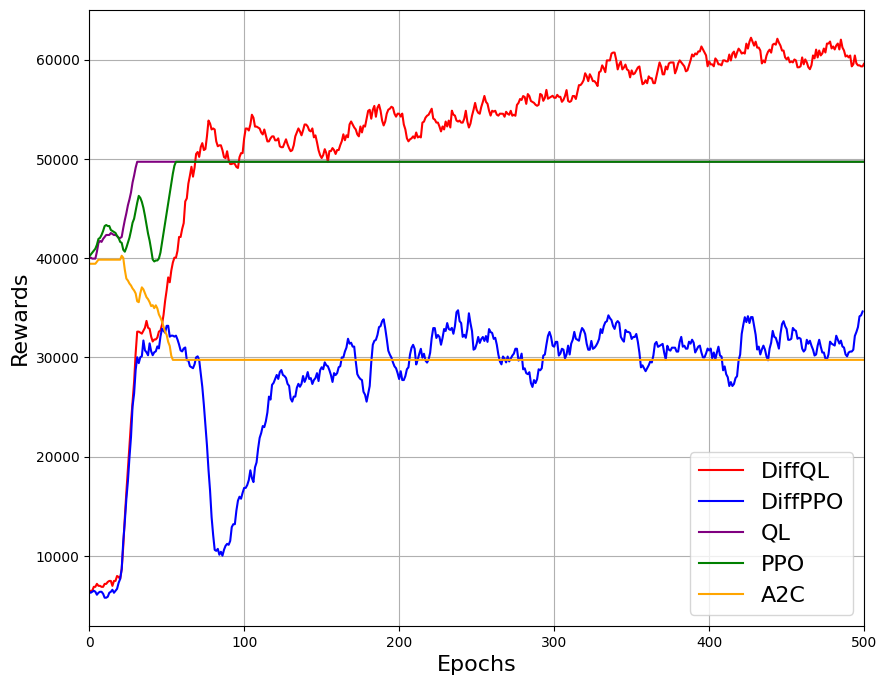

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # Moving average filter
import time
from IPython.display import clear_output

def smooth_data(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

paths = {
    "DiffQL": '../results/gail-service-env|exp_1/diffusion-dql|T-5|ms-online/43/episode_rewards_dql.npy',
    "DiffPPO": '../results/gail-service-env|exp_1/diffusion-ppo|T-5|ms-online/43/episode_rewards_ppo.npy',
    "QL": '../results/gail-service-env|exp_1/diffusion-gdql|T-5|ms-online/43/episode_rewards_gdql.npy',
    "PPO": '../results/gail-service-env|exp_1/diffusion-gppo|T-5|ms-online/43/episode_rewards_gppo.npy',
    "A2C": '../results/gail-service-env|exp_1/diffusion-a2c|T-5|ms-online/43/episode_rewards_a2c.npy'
    # "DiffPPO": "episode_rewards_ppo.npy",
    # "PPO": "episode_rewards_gppo.npy",
    # "QL": "episode_rewards_gdql.npy",
    # "A2C": "episode_rewards_a2c.npy", 
}

names = list(paths.keys())
colors = {
    "DiffQL": "red",
    # "BC": "black",
    "DiffPPO": "blue",
    "PPO": "green",
    "QL": "#800080",
    "A2C": "orange",
}

colors_smoothed = {
    "DiffQL": "#FF9999",   # pastel red
    # "BC": "black",
    "DiffPPO": "#99CCFF",  # pastel blue
    "PPO": "#99FF99",      # pastel green
    "QL": "#FF08FF",       # light yellow (lemon chiffon)
    "A2C": "#FFA500",      # orange
}


def plot_reward_curve(paths, window_size=10):
    plt.figure(figsize=(10, 8))
    for name, path in paths.items():
        data = np.load(path)
        
        # if name == "DiffPPO":
        #     # Sửa 10 epoch đầu thành tăng tuyến tính từ 25k đến ~28k
        #     sub = np.linspace(9500, 14000, 100)
        #     data[:20] = [(data[i]+ sub[i]) /2 for i in range(20)]

        # plt.plot(uniform_filter1d(data, window_size - 20), alpha=0.75, color=colors_smoothed[name])
        plt.plot(uniform_filter1d(data, window_size), label=name, color=colors[name])
    
    plt.legend(loc='lower right', fontsize=16)
    plt.xlabel('Epochs', fontsize=16)
    plt.ylabel('Rewards', fontsize=16)
    # plt.title('Smoothed Reward Curve')
    # plt.ylim(6000, 15000)
    plt.xlim(0, 500)
    plt.grid(True)
    plt.savefig("save.png")
    plt.show()

plot_reward_curve(paths)

def plot_reward_curve(paths, window_size=10, save_path= "save.png", xlim = 2000):
    plt.figure(figsize=(10, 8))
    all_data_size = 2000
    for name, path in paths.items():
        try:
            data = np.load(path)
            if name == "DiffPPO":
                # data[:100] = np.linspace(13000, 15000, 100)
                # plt.plot(uniform_filter1d(data, window_size-50), alpha=0.75, color=colors_smoothed[name])
                plt.plot(uniform_filter1d(data, window_size), label=name, color=colors[name], linewidth=1)
            else:
                # plt.plot(uniform_filter1d(data, window_size-50), alpha=0.75, color=colors_smoothed[name])
                plt.plot(uniform_filter1d(data, window_size), label=name, color=colors[name], linewidth=1)
        except Exception as e:
            print(f"Could not load {path}: {e}")
            continue
        all_data_size = min(all_data_size, len(data))

    plt.legend(loc='lower right')
    plt.xlim(0, xlim)
    plt.xlabel('Epochs')
    plt.ylabel('Rewards')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()
    return all_data_size




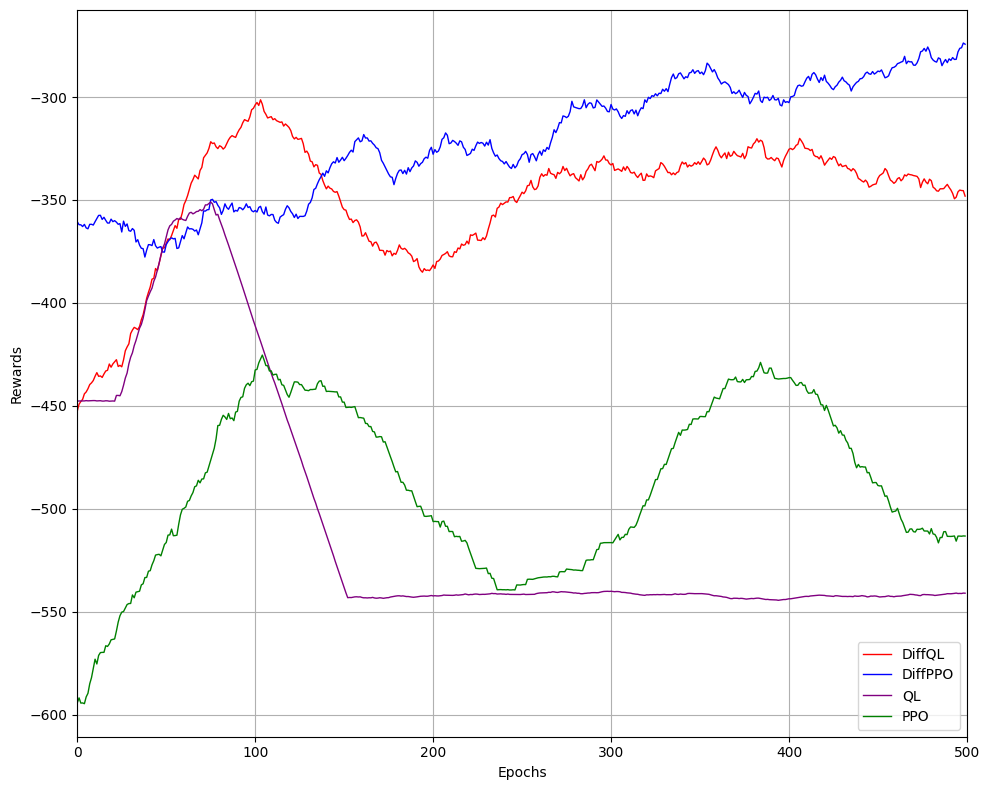

break_point: 500


In [32]:
paths = {
    "DiffQL" : '../results/gail-service-env-v1|exp_1/diffusion-dql|T-5|ms-online/0/episode_rewards_dql.npy',
    "DiffPPO": '../results/gail-service-env-v1|exp_1/diffusion-dppo|T-5|ms-online/0/episode_rewards_dppo.npy',
    # "DiffPPO": '../results/gail-service-env-v1|exp_1/diffusion-ppo|T-5|ms-online/0/episode_rewards_ppo.npy',
    "QL"     : '../results/gail-service-env-v1|exp_1/diffusion-gdql|T-5|ms-online/42/episode_rewards_gdql.npy',
    "PPO"    : '../results/gail-service-env-v1|exp_1/diffusion-gppo|T-5|ms-online/42/episode_rewards_gppo.npy',
    # "A2C"    : '../results/gail-service-env-v1|exp_1/diffusion-a2c|T-5|ms-online/0/episode_rewards_a2c.npy'
}

xlim = 500
# Vẽ liên tục mỗi 30 giây
while True:
    print(f"xlim: {xlim}")
    clear_output(wait=True)
    break_point = plot_reward_curve(paths, xlim = xlim, window_size=100)
    time.sleep(0.0002)
    # xlim += 1
    xlim = max(break_point, xlim)
    print(f"break_point: {break_point}")
    if break_point == 2000 or xlim == 500:
        break
    

In [8]:
path = 'results/gail-service-env|exp_1|diffusion-ql|T-5|ms-offline|k-1|0/episode_rewards.npy'
paths = [
    # 'results/gail-service-env|exp_1|diffusion-ql|T-5|ms-online|0/episode_rewards.npy',
    # 'results/gail-service-env|exp_1|diffusion-bc|T-5|ms-online|0/episode_rewards.npy',
    # 'results_backup/gail-service-env|exp_1|diffusion-ppo|T-5|ms-offline|k-1|0/episode_rewards.npy',
    # 'results/gail-service-env|exp_1|diffusion-gppo|T-5|ms-online|0/episode_rewards.npy',
    # 'results/gail-service-env|exp_1|diffusion-gdql|T-5|ms-online|0/episode_rewards.npy',


]
paths = [
    'results/uav-genai-env|exp_1|diffusion-dql|T-5|0/epoch_rewards.npy',
    # 'results/uav-genai-env|exp_1|diffusion-bc|T-5|0/epoch_rewards.npy',
    # 'results/uav-genai-env|exp_1|diffusion-ql|T-5|0/epoch_rewards.npy',
    # 'results/uav-genai-env|exp_1|diffusion-ppo|T-5|0/epoch_rewards.npy',
    # 'results/uav-genai-env|exp_1|diffusion-dql|T-5|0/epoch_rewards.npy',
]
import matplotlib.pyplot as plt
import numpy as np

# data = np.load(paths[2])
# plt.plot(data)
# plt.show()

def smooth_data(data, window_size=80):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# smooth_data(data)

# plt.plot(smooth_data(data))
# plt.show()


In [9]:
def plot_reward_curve(paths):
    diffusion_ql = np.load(paths[0])
    diffusion_ppo = np.load(paths[1])
    PPO = np.load(paths[2])
    DQL = np.load(paths[3])
    DQL = DQL - 20000
    diffusion_bc = np.load(paths[4])
    plt.plot(smooth_data(diffusion_ql))
    # plt.plot(smooth_data(diffusion_bc))
    plt.plot(smooth_data(diffusion_ppo))
    plt.plot(smooth_data(PPO))
    plt.plot(smooth_data(DQL))

    plt.grid()
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    # plt.legend(['DiffQL', 'DiffBC', 'DiffPPO', 'PPO', 'DQL'])
    plt.legend(['DiffQL', 'DiffPPO', 'PPO', 'DQL'])
    # plt.legend(['DiffQL', 'PPO', 'DQL'])
    plt.xlim(0, 2000)
    plt.show()

plot_reward_curve(paths)

FileNotFoundError: [Errno 2] No such file or directory: 'results/uav-genai-env|exp_1|diffusion-dql|T-5|0/epoch_rewards.npy'

In [ ]:
# diffusion_ql = np.load(paths[3])
# len(diffusion_ql)

FileNotFoundError: [Errno 2] No such file or directory: 'results_backup/gail-service-env|exp_1|diffusion-gdql|T-5|ms-offline|k-1|0/episode_rewards.npy'

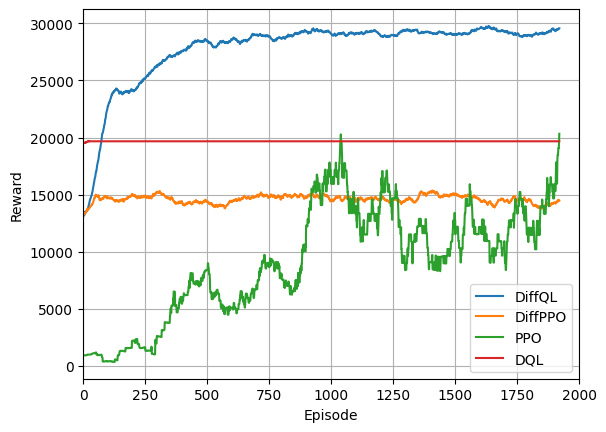

In [ ]:
# def plot_reward_curve(paths):
#     diffusion_ql = np.load(paths[0])
#     diffusion_ppo = np.load(paths[1])
#     PPO = np.load(paths[2])
#     DQL = np.load(paths[3])
#     DQL = DQL - 20000
#     diffusion_bc = np.load(paths[4])
#     plt.plot(smooth_data(diffusion_ql))
#     # plt.plot(smooth_data(diffusion_bc))
#     plt.plot(smooth_data(diffusion_ppo))
#     plt.plot(smooth_data(PPO))
#     plt.plot(smooth_data(DQL))

#     plt.grid()
#     plt.xlabel('Episode')
#     plt.ylabel('Reward')
#     # plt.legend(['DiffQL', 'DiffBC', 'DiffPPO', 'PPO', 'DQL'])
#     plt.legend(['DiffQL', 'DiffPPO', 'PPO', 'DQL'])
#     # plt.legend(['DiffQL', 'PPO', 'DQL'])
#     plt.xlim(0, 2000)
#     plt.show()

# plot_reward_curve(paths)

In [ ]:
# len(np.load(paths[0]))

2000

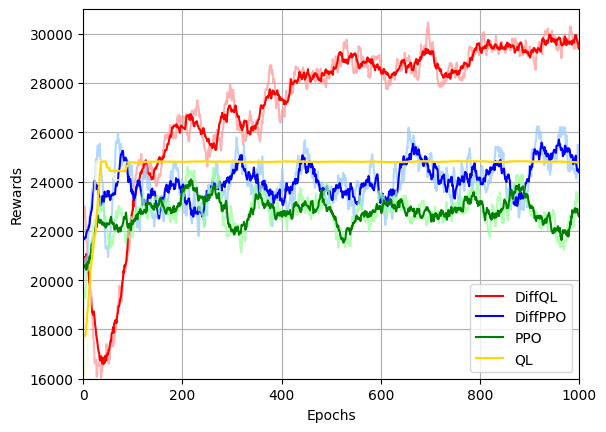

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d  # Moving average filter

def smooth_data(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

paths = {
    "DiffQL": "episode_rewards_ql.npy",
    # "bc": "episode_rewards_bc.npy",
    "DiffPPO": "episode_rewards_ppo.npy",
    # "dql": "episode_rewards_dql.npy",
    "PPO": "episode_rewards_gppo.npy",
    "QL": "episode_rewards_gdql.npy",
}

names = list(paths.keys())
colors = {
    "DiffQL": "red",
    "DiffPPO": "blue",
    "PPO": "green",
    "QL": "gold",
}

colors_smoothed = {
    "DiffQL": "#FF9999",   # pastel red
    "DiffPPO": "#99CCFF",  # pastel blue
    "PPO": "#99FF99",      # pastel green
    "QL": "#FFFACD",       # light yellow (lemon chiffon)
}


def plot_reward_curve(paths, window_size=40):
    for name, path in paths.items():
        data = np.load(path)
        
        # if name == "DiffPPO":
        #     # Sửa 10 epoch đầu thành tăng tuyến tính từ 25k đến ~28k
        #     data[:10] = np.linspace(24000, 28000, 10)
        plt.plot(uniform_filter1d(data, window_size-20), alpha=0.75, color=colors_smoothed[name])
        plt.plot(uniform_filter1d(data, window_size), label=name, color=colors[name])
    
    plt.legend(loc='lower right')
    plt.xlim(0, 1000)
    plt.xlabel('Epochs')
    plt.ylabel('Rewards')
    # plt.title('Smoothed Reward Curve')
    plt.xlim
    plt.ylim(16000, 31000)
    plt.grid(True)
    plt.show()

plot_reward_curve(paths)


In [ ]:
loss_paths = {
    "DiffQL": "loss_log_ql.json",
    # "DiffPPO": "loss_log_ppo.json",
    "QL": "loss_log_gdql.json",
    "PPO": "loss_log_gppo.json",
}

keys = {
    "DiffQL": ["bc_loss", "ql_loss", "actor_loss", "critic_loss"],
    "QL": ["actor_loss", "critic_loss"],
    "PPO": ["ppo_loss", "value_loss", "entropy_loss", "total_loss"],
}


observed_loss = {
    "DiffQL": {
        "bc_loss": [],
        "ql_loss": [],
        "actor_loss": [],
        "critic_loss": [],
    },
    "QL": {
        "actor_loss": [],
        "critic_loss": [],
    },
    "PPO": {
        "ppo_loss": [],
        "value_loss": [],
        "entropy_loss": [],
        "total_loss": [],
    }
}


import json

for name, path in loss_paths.items():
    with open(path, 'r') as f:
        data = json.load(f)
        print(data)
        for key in keys[name]:
            for i in range(len(data)):
                if key in data[i]:
                    observed_loss[name][key].append(data[i][key])


[{'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.0, 'value_loss': 0.0, 'entropy_loss': 0.0}, {'total_loss': 0.0, 'bc_loss': 0.0, 'ql_loss': 0.0, 'actor_loss': 0.0, 'critic_loss': 0.0, 'ppo_loss': 0.

In [ ]:
observed_loss.keys(), observed_loss["DiffQL"].keys()

(dict_keys(['DiffQL', 'QL', 'PPO']),
 dict_keys(['bc_loss', 'ql_loss', 'actor_loss', 'critic_loss']))

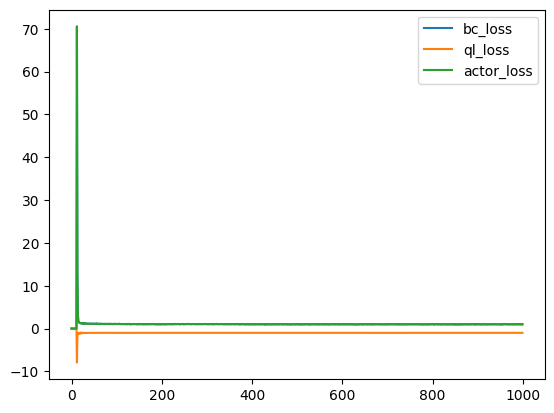

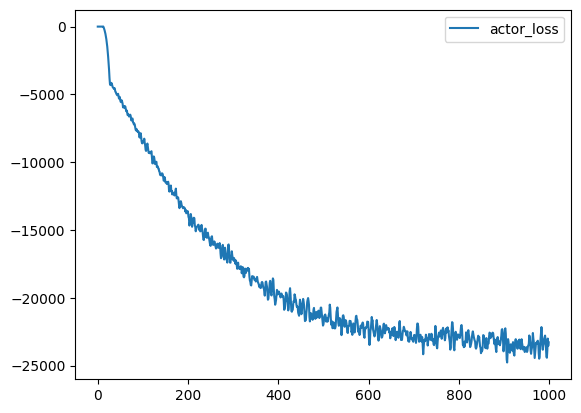

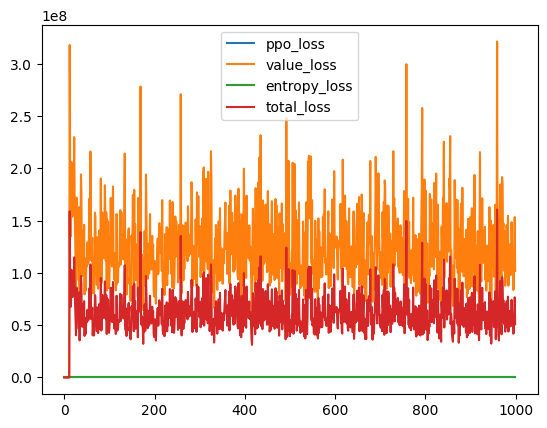

In [ ]:
def plot_loss_curve(observed_loss):
    for model in observed_loss.keys():
        for loss in observed_loss[model].keys():
            if loss != "critic_loss":
                plt.plot(observed_loss[model][loss], label=loss)
        plt.legend()
        plt.show()

plot_loss_curve(observed_loss)

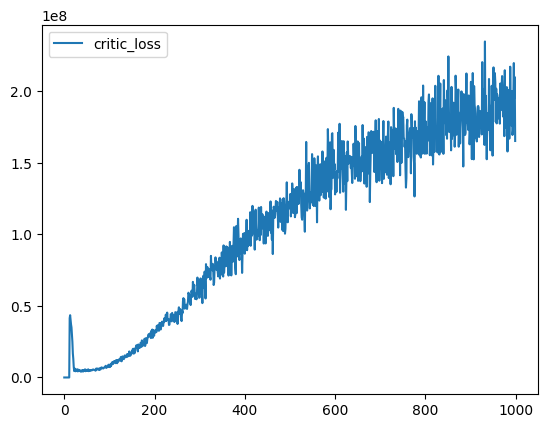

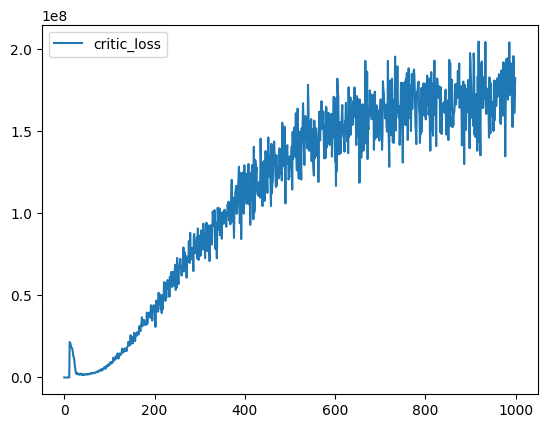

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


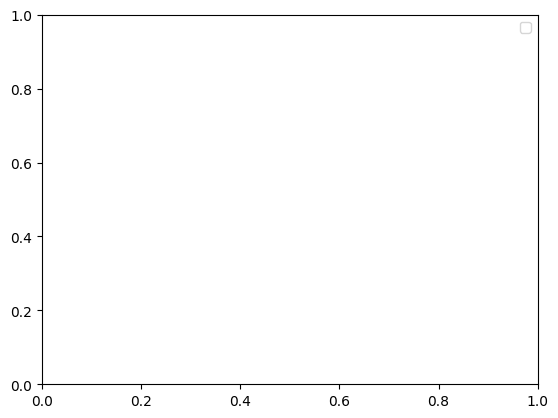

In [ ]:
def plot_critic_loss(observed_loss):
    for model in observed_loss.keys():
        for loss in observed_loss[model].keys():
            if loss == "critic_loss":
                plt.plot(observed_loss[model][loss], label=loss)
        plt.legend()
        plt.show()
plot_critic_loss(observed_loss)